## Домашнее задание: "Детекция объектов на изображении"

ФИО:

## Цель задания:
Научиться самостоятельно решать задачу детекции.
## Описание задания:
В рамках данного домашнего задания предлагается решить задачу детекции мячей и настроить полный пайплайн обучения модели.

Процесс выполнения задания следующий:

0. Выбор модели детекции для обучения:
    1. Выберите модель детекции для выполнения домашнего задания. Любую, кроме RetinaNet. Ее реализацию можно взять из открытых источников. Модель можно брать предобученную ( в этом случае в пункте 4. показать влияние предобучения на финальное качество).
    2. Полезные ссылки: [PyTorch Vision Models](https://pytorch.org/vision/stable/models.html) (блок Object Detection), [SOTA модели детекции](https://paperswithcode.com/sota/object-detection-on-coco), [Возможный пример кода](https://github.com/AlekseySpasenov/dl-course/blob/autumn_2023/lecture8/detection_example/pytorch_detection_workshop.ipynb)
    3. Вы можете использовать RetinaNet, которая была реализована на семинаре, но это приведет к снижению оценки на **–2.5 балла**, так как задания 1.1 и 2.1 уже были выполнены в рамках занятия.

1. Подготовка обучающего набора данных
    0. Для выполнения задания используйте датасет с изображениями мячей, который использовался на семинаре.
    1. Реализуйте корректный класс Dataset и Dataloader для выбранной модели (должен работать форвард вашей модели на том, что выходит из даталоадера) **0.5 балла**.
    2. Добавьте простые аугментации в датасет (аугментации, не затрагивающие изменение ground-truth bounding box) **0.5 балла**.
    3. Внедрите сложные аугментации (аугментации, затрагивающие изменение ground-truth bounding box. Например, аффинные преобразования: сдвиг, поворот и т.д.) **0.5 балла**.

    4. Полезные ссылки: https://pytorch.org/vision/stable/transforms.html , https://albumentations.ai

2. Реализация корректного train-loop и обучение модели:  
    1. Реализуйте эффективный train-loop для вашей модели и проведите обучение **2 балла**.
    2. Выполните несколько запусков обучения с различными параметрами, например: сравните влияние различных аугментаций, оцените влияние того была предобучена модель или нет, сравните результаты при изменении гиперпараметров итд (на ваш выбор) **0.5 балла**.

3. Валидация обученных моделей на тестовой выборке, вычисление метрики mAP
    1. Оцените качество моделей на тестовой части данных и рассчитайте метрику mAP **0.5 балл**
    2. Полезные ссылки: [mean_average_precision](https://github.com/bes-dev/mean_average_precision)

4. Выводы **0.5 балл**:
    1. Проанализируйте результаты обучения, визуально оцените качество работы модели.
    2. Прокомментируйте распространенные ошибки модели и предложите пути для улучшения финального решения.

## Решение ДЗ

1. Скачивание данных для обучения

In [1]:
# !gdown "https://drive.google.com/uc?id=1ZMPIHcEVOZx9OukDOGvmkndkVGYpmIEF" -O seminar_objdet_retina_oi5_ball.zip

In [2]:
# !unzip seminar_objdet_retina_oi5_ball.zip

In [3]:
# !rm seminar_objdet_retina_oi5_ball.zip

2. Выбор модели FasterRCNN ResNet50

In [4]:
from typing import Optional
import json
import os

In [5]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.nn as nn

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')

2. DataSet and DataLoader

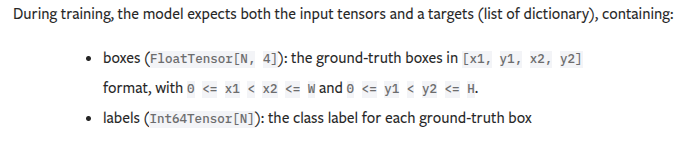

In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

In [8]:
class ds_FasterRCNN_ResNet50_FPN(Dataset):
    def __init__(self, img_dir: str, train: bool = False, transform: Optional[A.Compose] = None):
        self.img_dir = img_dir
        self.train = train
        self.transform: Optional[A.Compose] = transform
        self.data_dict: Optional[dict] = None
        
        self._read_files()

    def _read_files(self):
        if self.img_dir is None or not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"Image dir '{self.img_dir}' does not exist.")
        
        filename = "oi5_ball_filename_to_bbox_train.json" if self.train else "oi5_ball_filename_to_bbox_val.json"
        
        json_path = os.path.join(self.img_dir, filename)

        if not os.path.exists(json_path):
            raise FileNotFoundError(f"Annotation file not found: {json_path}")
        
        with open(json_path, "r") as f:
            self.data_dict = json.load(f)

        self.images_paths = list(self.data_dict.keys())

    def __len__(self):
        return self.images_paths.__len__()
    
    def __getitem__(self, index):
        img_name = self.images_paths[index]
        img_path = os.path.join(self.img_dir, img_name)
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.
        h, w = image.shape[:2]

        bboxes_norm = self.data_dict[img_name]
        bboxes = []
        for (xmin, xmax, ymin, ymax) in bboxes_norm:
            x_min = xmin * w
            x_max = xmax * w
            y_min = ymin * h
            y_max = ymax * h
            bboxes.append([x_min, y_min, x_max, y_max])
        
        labels = [1] * len(bboxes)
        
        if self.transform is not None:
            augmented = self.transform(image=image, bboxes=bboxes, labels=labels)
            augmented_bboxes = torch.tensor(augmented['bboxes'], dtype=torch.float32)
            labels = torch.tensor(augmented['labels'], dtype=torch.int64)
        
            target = {
                'boxes': augmented_bboxes,
                'labels': labels
            }
        
            return augmented['image'], target
        else:
            target = {
                'boxes' : bboxes,
                'labels' : labels
            }
            return image, target
        

Аугментации датасета

1. Простые аугментации

In [9]:
simple_transform = A.Compose([
    A.RandomBrightnessContrast(p=1),
    A.HueSaturationValue(p=1),
    # A.Normalize(),
], bbox_params=A.BboxParams(format='pascal_voc',
                            label_fields=['labels'],
                            )
)

/home/Applications/Data/programming/2025/data-portfolio/skils/NN_skils/.venv/lib/python3.12/site-packages/albumentations/core/composition.py:361: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


In [10]:
train_dataset = ds_FasterRCNN_ResNet50_FPN('seminar_objdet_retina_oi5_ball', train=True, transform=None)

In [11]:
def vizualize(ax, image, bboxes):
    ax.imshow(image)
    for box in bboxes:
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=1,
            edgecolor="red",
            fill=False
        )
        ax.add_patch(rect)
        

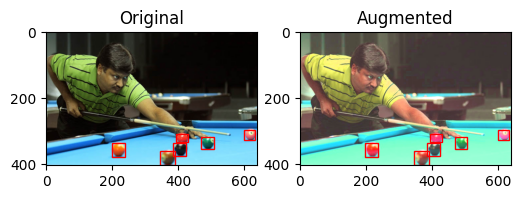

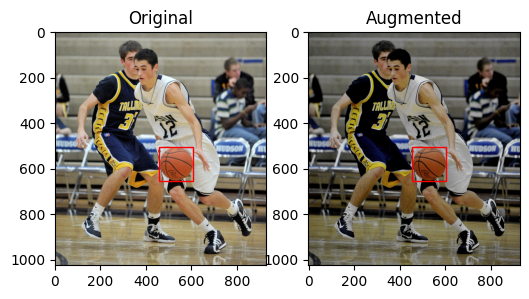

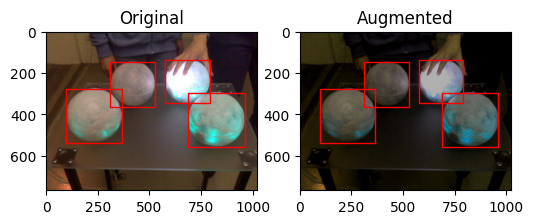

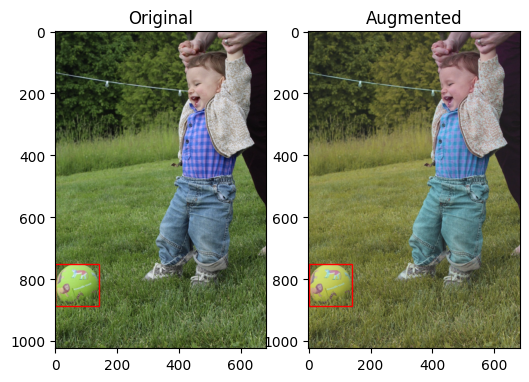

In [12]:
for i in range(4):
    image, target = train_dataset[i]
    augmented = simple_transform(image=image, bboxes=target['boxes'], labels=target['labels'])
    
    image_aug = augmented['image']
    bboxes_aug = augmented['bboxes']
    
    fig, axes = plt.subplots(1, 2, figsize=(6,6))
    
    axes[0].set_title('Original')
    vizualize(axes[0], image, target['boxes'])
    
    axes[1].set_title('Augmented')
    vizualize(axes[1], image_aug, bboxes_aug)
    plt.show()

2. Сложные аугментации

In [13]:
complex_transform = A.Compose([
    A.RandomCrop(width=450, height=450, p=1, pad_if_needed=True),
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='pascal_voc',
                            label_fields=['labels'],
                            )
)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[[ 38.99999237 356.99995458  78.99999237 400.00008345]
 [186.99998474 380.9998244  231.99967957 425.00017583]
 [225.99969482 356.99995458 265.99969482 397.99996018]
 [233.99968719 330.99998832 271.99967957 354.99985814]
 [311.         338.99997175 348.00031281 374.99993742]
 [441.         318.99986565 450.         349.99984503]]


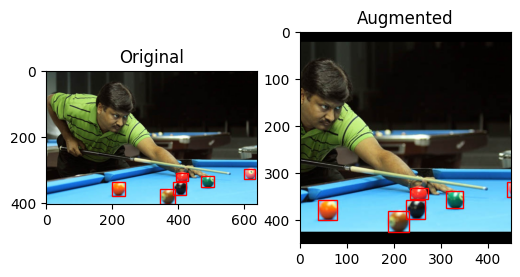

[]
[]


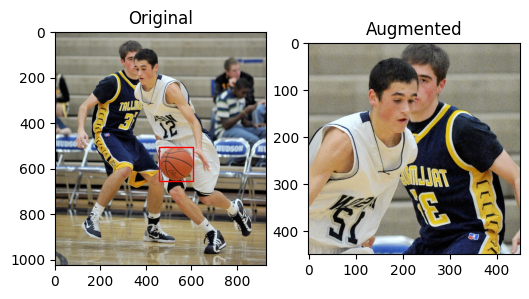

[1.0, 1.0]
[[150.55999756   0.         418.08000183 232.59999084]
 [  0.           0.         204.95999146  59.1602478 ]]


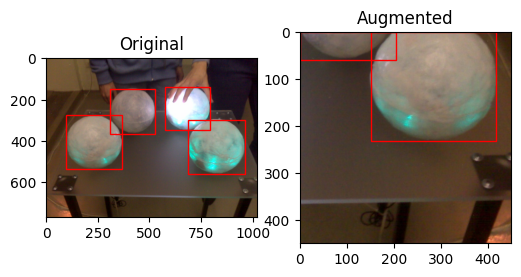

[]
[]


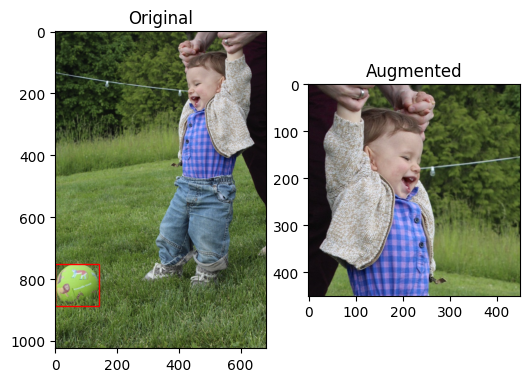

In [14]:
for i in range(4):
    image, target = train_dataset[i]
    augmented = complex_transform(image=image, bboxes=target['boxes'], labels=target['labels'])
    
    image_aug = augmented['image']
    bboxes_aug = augmented['bboxes']
    labels_aug = augmented['labels']
    
    fig, axes = plt.subplots(1, 2, figsize=(6,6))
    
    axes[0].set_title('Original')
    vizualize(axes[0], image, target['boxes'])
    
    axes[1].set_title('Augmented')
    print(labels_aug)
    print(bboxes_aug)
    vizualize(axes[1], image_aug, bboxes_aug)
    plt.show()

Работа с моделью

In [15]:
train_transform = A.Compose([
    A.Resize(600, 600),
    A.RandomBrightnessContrast(p=0.2),
    A.HueSaturationValue(p=0.2),
    # A.RandomCrop(width=200, height=200, p=0.2, pad_if_needed=True),
    A.HorizontalFlip(p=0.5),
    A.ToFloat(max_value=255),
    # A.Normalize(mean=(0.485, 0.456, 0.406),
    #             std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc',
                            label_fields=['labels'],
                            )
)

test_transform = A.Compose([
    A.Resize(600, 600),
    A.ToFloat(max_value=255),
    # A.Normalize(mean=(0.485, 0.456, 0.406),
    #             std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc',
                            label_fields=['labels'],
                            )
)

In [16]:
train_dataset = ds_FasterRCNN_ResNet50_FPN('seminar_objdet_retina_oi5_ball', train=True, transform=train_transform)
test_dataset = ds_FasterRCNN_ResNet50_FPN('seminar_objdet_retina_oi5_ball', train=False, transform=test_transform)

In [17]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [18]:
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

Цикл обучения модели

In [19]:
from tqdm import tqdm

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)


In [75]:
from mean_average_precision import MetricBuilder

class MAPLoss(nn.modules.loss._Loss):
    def __init__(self, num_classes: int = 1, iou_threshold: float = 0.5):
        super().__init__()
        self.num_classes = num_classes
        self.iou_threshold = iou_threshold
        self.metric_fn = MetricBuilder.build_evaluation_metric(
            "map_2d", async_mode=False, num_classes=self.num_classes
        )
    
    def forward(self, input: torch.Tensor, target: torch.Tensor):
        num_objs = target['boxes'].shape[0]

        gt_labels = (target['labels'].detach().cpu().numpy().reshape(-1,1)).astype(np.int32)
        pred_labels = (input['labels'].detach().cpu().numpy().reshape(-1,1)).astype(np.int32)

        gt = np.concatenate((
            target['boxes'].detach().cpu().numpy(),
            gt_labels,
            np.zeros((num_objs, 2))
        ), axis=1)

        pred = np.concatenate((
            input['boxes'].detach().cpu().numpy(),
            pred_labels,
            input['scores'].detach().cpu().numpy().reshape(-1, 1)
        ), axis=1)

        self.metric_fn.add(pred, gt)
        

In [21]:
def denormilize_image(image: torch.Tensor):
    
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    mean = mean[:, None, None]
    std = std[:, None, None]
    
    image = image * std + mean
    return image.clamp(0, 1)

In [22]:
def vizualize_answer_batch(images, answers, threshold = 0.5, target = None):
    batch_size = len(images)
    n_cols = 2
    n_rows = (batch_size + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten()
    
    for idx, (img, answer) in enumerate(zip(images, answers)):
        ax = axes[idx]
        img = img.permute(1, 2, 0).cpu().numpy()
        ax.imshow((img * 255).astype('uint8'))
        ax.axis('off')
        
        bboxes = answer['boxes']
        labels = answer['labels']
        scores = answer['scores']
        
        for box, score in zip(bboxes, scores):
            if (score.item() > threshold):
                x_min, y_min, x_max, y_max = box.detach().cpu().numpy()
                rect = patches.Rectangle(
                    (x_min, y_min),
                    x_max - x_min,
                    y_max - y_min,
                    linewidth=1,
                    edgecolor="red",
                    fill=False,
                )
                ax.add_patch(rect)
                
        if target is not None:
            bboxes = target[idx]['boxes']
            for box in bboxes:
                x_min, y_min, x_max, y_max = box.cpu().numpy()
                rect = patches.Rectangle(
                    (x_min, y_min),
                    x_max - x_min,
                    y_max - y_min,
                    linewidth=1,
                    edgecolor="green",
                    fill=False,
                )
                ax.add_patch(rect)
            
    plt.show()

In [58]:
import time

In [65]:
class TrainModel:
    def __init__(self, model,
                 train_loader,
                 val_loader,
                 optimizer,
                 criterion,
                 device,
                 sheduler=None
                 ):
        self.model: nn.Module = model.to(device=device)
        self.train_loader: DataLoader = train_loader
        self.val_loader: DataLoader = val_loader
        self.optimizer: torch.optim.Optimizer = optimizer
        self.criterion: MAPLoss = criterion
        self.device: torch.device = device
        self.sheduler: Optional[torch.optim.lr_scheduler.LRScheduler] = sheduler
        
        
        self.train_loss = []
        self.val_loss = []
        self.mAP_metric = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0
        loop = tqdm(enumerate(self.train_loader), total=len(self.train_loader), desc="Training")
        for idx, (image, target) in loop:
 
            images = [img.to(device) for img in image]
            targets = [{k: v.to(device) for k, v in t.items()} for t in target]
            
            output = self.model(images, targets)
            losses = sum(loss for loss in output.values())
            
            total_loss += losses.item()
            
            loop.set_postfix({'avg_train_loss': f'{total_loss / (idx + 1):.4f}'})
            
            self.optimizer.zero_grad()
            losses.backward()
            self.optimizer.step()
            
            if idx in list(range(0, len(self.train_loader), 500)):
                self.model.eval()
                output = self.model(images)
                vizualize_answer_batch(images, output, threshold=0.5, target=targets)
                self.model.train()
        
        if self.sheduler is not None:
            self.sheduler.step()
            
        avg_loss = total_loss / len(self.train_loader)
        return avg_loss
    
    def val_epoch(self):
        self.model.train()
        total_loss = 0
        with torch.no_grad():
            loop = tqdm(enumerate(self.val_loader), total=len(self.val_loader), desc="Validate")
            for idx, (image, target) in loop:
                images = [img.to(device) for img in image]
                targets = [{k: v.to(device) for k, v in t.items()} for t in target]
                
                output = self.model(images, targets)
                
                losses = sum(loss for loss in output.values())
                
                total_loss += losses.item()
                
                loop.set_postfix({'avg_val_loss': f'{total_loss / (idx + 1):.4f}'})
                
            if idx in list(range(0, len(self.train_loader), 70)):
                vizualize_answer_batch(images, output, target=targets)
                
        avg_loss = total_loss / len(self.val_loader)
        return avg_loss
    
    def metric(self, threshold=0.05):
        self.model.eval()
        self.criterion.metric_fn.reset()
        
        with torch.no_grad():
            loop = tqdm(enumerate(self.val_loader),
                        total=len(self.val_loader),
                        desc="Validate mAP")
            
            for idx, (images, targets) in loop:
                images = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

                outputs = self.model(images)

                for out, targ in zip(outputs, targets):
                    keep = out["scores"] >= threshold
                    boxes = out["boxes"][keep].detach().cpu().numpy()
                    scores = out["scores"][keep].detach().cpu().numpy()
                    labels = out["labels"][keep].detach().cpu().numpy()

                    gt_boxes = targ["boxes"].detach().cpu().numpy()
                    gt_labels = targ["labels"].detach().cpu().numpy()

                    preds = np.concatenate(
                        [boxes, labels[:, None], scores[:, None]], axis=1
                    )

                    num_gt = gt_boxes.shape[0]
                    difficult = np.zeros((num_gt, 1))
                    crowd = np.zeros((num_gt, 1))
                    gts = np.concatenate(
                        [gt_boxes, gt_labels[:, None], difficult, crowd], axis=1
                    )

                    self.criterion.metric_fn.add(preds, gts)

        result = self.criterion.metric_fn.value(
            iou_thresholds=self.criterion.iou_threshold,
            recall_thresholds=np.arange(0., 1.1, 0.1)
        )
        return result["mAP"]
    
    def train(self, epoch: int = 5):
        
        self.train_loss.clear()
        self.val_loss.clear()
        self.mAP_metric.clear()
        
        for i in range(epoch):
            print(f"Epoch {i + 1} \\ 5")
            self.train_loss.append(self.train_epoch())
            
            self.val_loss.append(self.val_epoch())
            
            self.mAP_metric.append(self.metric())
 

In [24]:
model = fasterrcnn_resnet50_fpn(FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)

for param in model.parameters():
    param.requires_grad = False
    
for param in model.roi_heads.box_predictor.parameters():
    param.requires_grad = True

model.to(device)

/home/Applications/Data/programming/2025/data-portfolio/skils/NN_skils/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Посчитаем метрику mAP для уже предобученной модели

In [25]:
optimizator = torch.optim.AdamW(model.parameters(), lr=1e-3)
sheduler = torch.optim.lr_scheduler.StepLR(optimizator, step_size=2, gamma=0.1)

In [ ]:
train = TrainModel(model, train_dataloader, test_dataloader, optimizator, MAPLoss(2, 0.5), device)

Epoch 1 \ 5


Training:   0%|          | 0/1438 [00:00<?, ?it/s, avg_train_loss=0.9832]

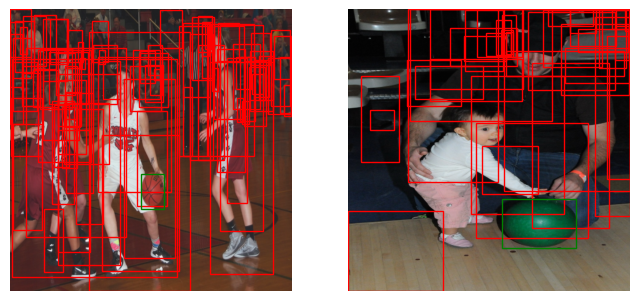

Training:  35%|███▍      | 500/1438 [03:07<05:49,  2.68it/s, avg_train_loss=0.2699]

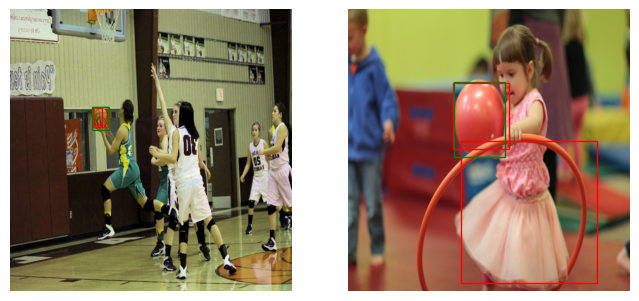

Training:  70%|██████▉   | 1000/1438 [06:14<02:44,  2.66it/s, avg_train_loss=0.2518]

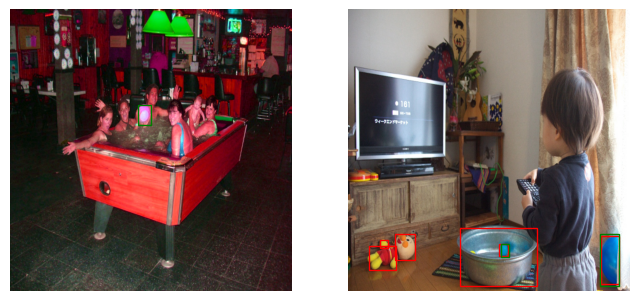

Validate mAP: 100%|██████████| 113/113 [00:48<00:00,  2.34it/s]


Epoch 2 \ 5


Training:   0%|          | 0/1438 [00:00<?, ?it/s, avg_train_loss=0.1950]

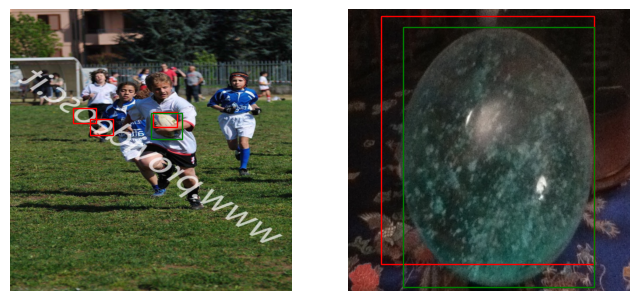

Training:  35%|███▍      | 500/1438 [03:07<05:44,  2.72it/s, avg_train_loss=0.2236]

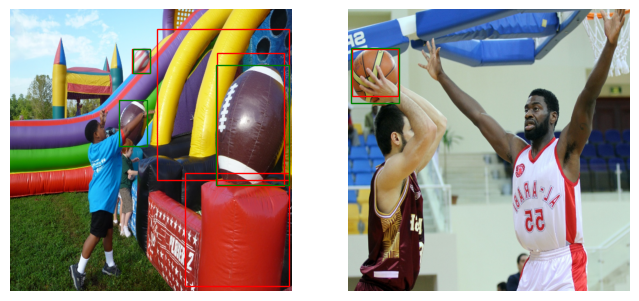

Training:  70%|██████▉   | 1000/1438 [06:14<02:44,  2.67it/s, avg_train_loss=0.2291]

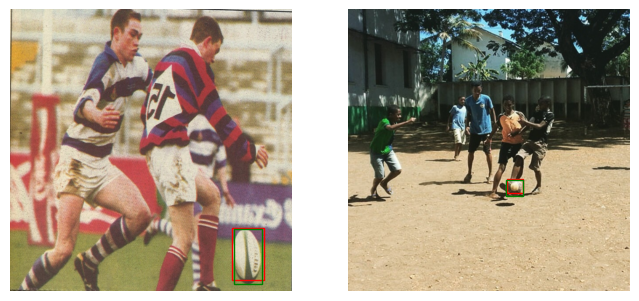

Validate mAP: 100%|██████████| 113/113 [00:48<00:00,  2.33it/s]


Epoch 3 \ 5


Training:   0%|          | 0/1438 [00:00<?, ?it/s, avg_train_loss=0.1015]

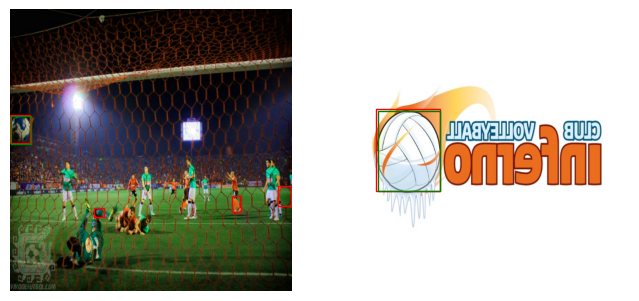

Training:  35%|███▍      | 500/1438 [03:07<05:50,  2.67it/s, avg_train_loss=0.2372]

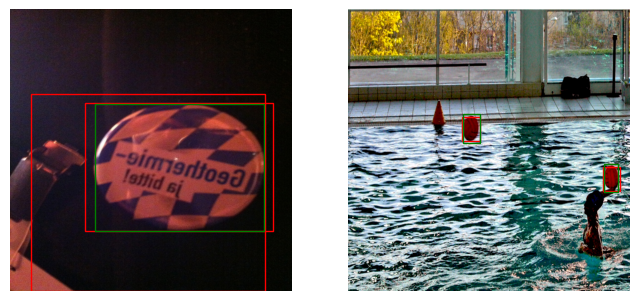

Training:  70%|██████▉   | 1000/1438 [06:14<02:43,  2.69it/s, avg_train_loss=0.2409]

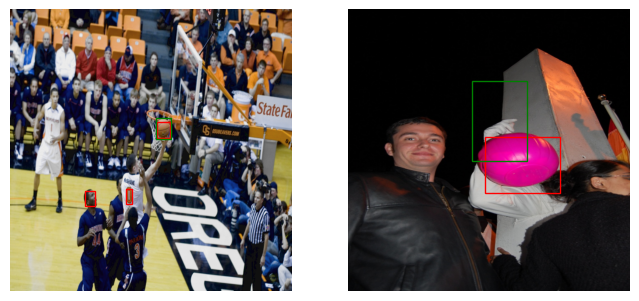

Validate mAP: 100%|██████████| 113/113 [00:48<00:00,  2.33it/s]


Epoch 4 \ 5


Training:   0%|          | 0/1438 [00:00<?, ?it/s, avg_train_loss=0.2012]

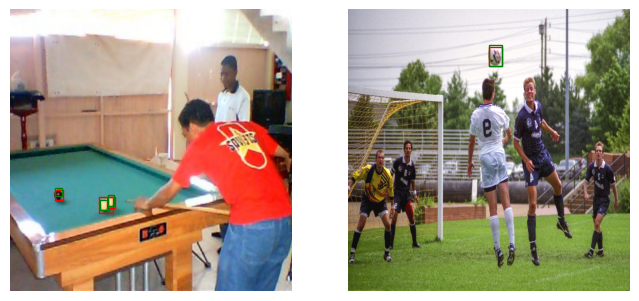

Training:  35%|███▍      | 500/1438 [03:07<05:50,  2.67it/s, avg_train_loss=0.2352]

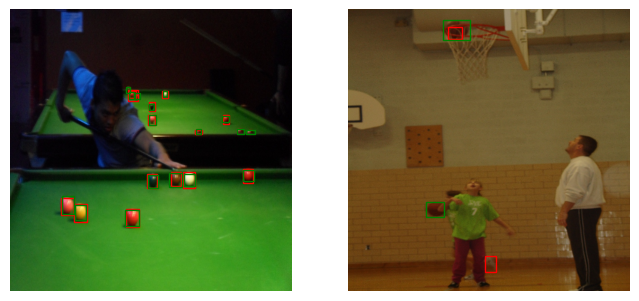

Training:  70%|██████▉   | 1000/1438 [06:14<02:42,  2.69it/s, avg_train_loss=0.2385]

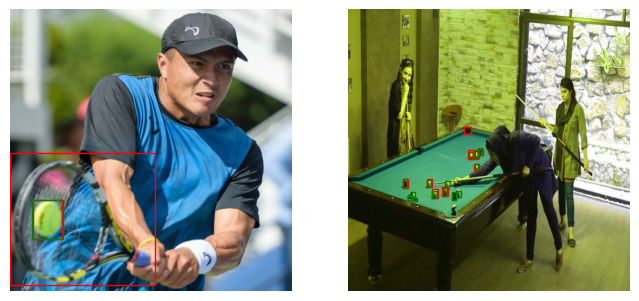

Validate mAP: 100%|██████████| 113/113 [00:48<00:00,  2.33it/s]


Epoch 5 \ 5


Training:   0%|          | 0/1438 [00:00<?, ?it/s, avg_train_loss=0.0814]

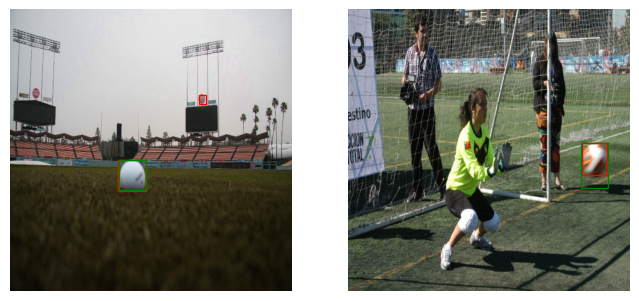

Training:  35%|███▍      | 500/1438 [03:07<05:49,  2.68it/s, avg_train_loss=0.2565]

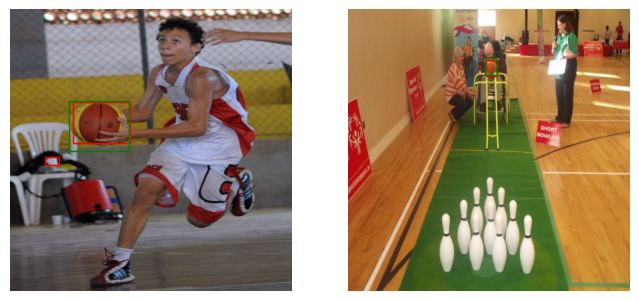

Training:  70%|██████▉   | 1000/1438 [06:14<02:42,  2.69it/s, avg_train_loss=0.2321]

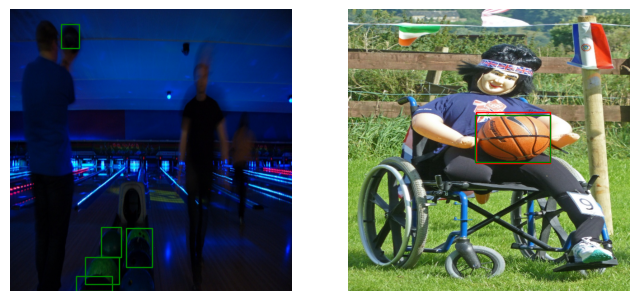

Validate mAP: 100%|██████████| 113/113 [00:48<00:00,  2.33it/s]


In [27]:
train.train()

image shape = torch.Size([3, 600, 600])
anser = tensor([[234.2383, 504.1914, 354.1770, 586.0937],
        [230.5707, 521.2482, 246.9697, 545.6882],
        [334.2467, 235.9367, 357.8925, 284.8921]], grad_fn=<StackBackward0>)
target = tensor([[233.0988, 506.2500, 352.8168, 584.5314]])


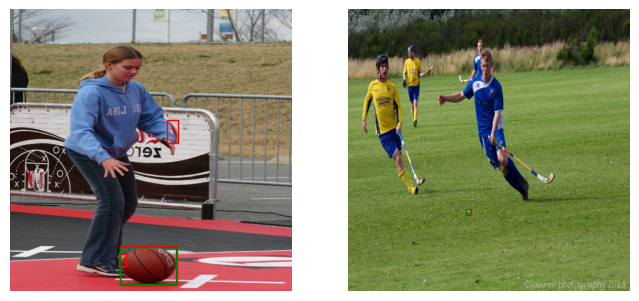

In [ ]:
for idx, (image, target) in enumerate(train_dataloader):
    images = [img for img in image]
    model = train.model.to(torch.device('cpu'))
    train.criterion = MAPLoss(2, 0.5)
    model.eval()
    answer = model(images)
    print(f"image shape = {image[0].shape}")
    print(f"anser = {answer[0]['boxes']}")
    print(f"target = {target[0]['boxes']}")
    vizualize_answer_batch(images, answer, threshold=0.05,target=target)
    break

In [29]:
torch.save(train.model.state_dict(), "fasterrcnn_weights.pth")

In [76]:
test = TrainModel(train.model, train_dataloader, test_dataloader, optimizator, MAPLoss(2, 0.5), device)
print(f"mAP50 = {test.metric(0.5)}")

Validate mAP: 100%|██████████| 113/113 [00:48<00:00,  2.35it/s]

mAP50 = 0.27705490589141846


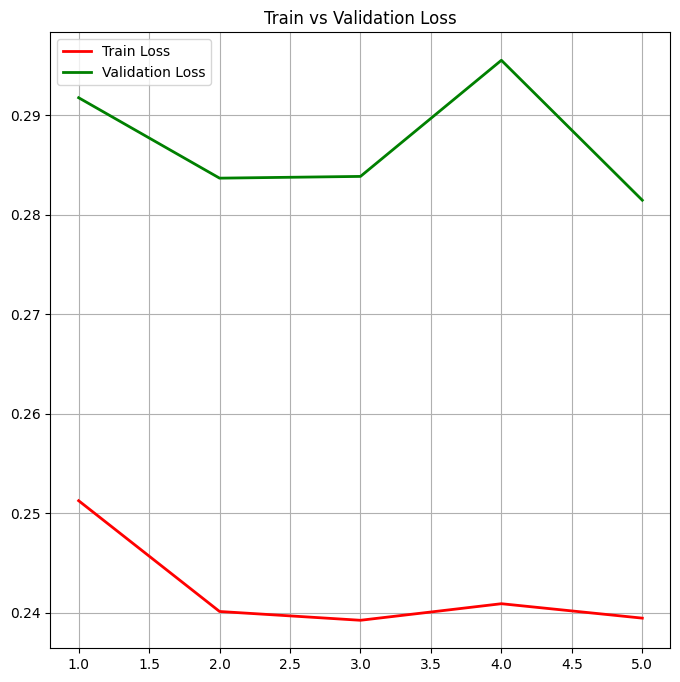

In [43]:
fig = plt.figure(figsize=(8, 8))


x = np.linspace(1, 5, 5)
plt.plot(x, train.train_loss, color="red", linewidth=2, label="Train Loss")
plt.plot(x, train.val_loss, color="green", linewidth=2, label="Validation Loss")

plt.title("Train vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

### Оставьте обратную связь по занятию №6
Это поможет улучшить курс и сделать следующие занятия ещё лучше!
Форма обратной связи: https://forms.gle/hTfRQaGBrqic7LyP6
